# Synthetic Data Generation

Now that the prompt and the sample selection algorithm are finalized, this code runs the synthetic data generation pipeline over all the 950 datapoints that need to be labeled. 

In [ ]:
!pip install faiss-cpu

In [ ]:
import os
import time
import logging
import openai
from tqdm import tqdm
from datasets import load_dataset, Dataset, concatenate_datasets
from openai import OpenAI
from sentence_transformers import SentenceTransformer
import faiss
import numpy as np
from datasets import Dataset
import re
import random
from sentence_transformers import SentenceTransformer, util
import torch
import ast


UNLABELED_DATASET_PATH = "businessrules/Code_snippets"

GOLDEN_DATASET_PATH = "businessrules/Golden_dataset"

NUM_FEW_SHOTS = 3

OUTPUT_DATASET_PATH = "businessrules/synthetic_dataset"

print ("done")

done


In [ ]:
import os
from openai import OpenAI

openai_api_key = os.getenv("OPENAI_API_KEY")
if not openai_api_key:
    raise ValueError("No OpenAI API key found. Please set OPENAI_API_KEY.")

client = OpenAI(api_key=openai_api_key)

MODEL = "gpt-4.1" 
print(f"Connected to OpenAI using model: {MODEL}")


Connected to OpenAI using model: gpt-4.1


In [ ]:
## Prompt 7
def build_prompt(few_shot_examples, current_code):
    system_prompt = (
        "You are an expert Business Rule Extraction Model. "
        "Your goal is to identify and formalize business rules embedded in source code. "
        "You think in ordered stages: first you learn from examples, then you extract, filter, and rewrite. "
        "Your outputs must include a readable markdown section for non-technical audiences. "
        "You must silently reason through all stages internally but only output the final markdown section — "
        "never show intermediate stages, reasoning text, or any explanation."
    )

    user_prompt = f"""
You are a **Business Rule Extraction Model** trained to convert code logic into formal, human-readable **business rules**.

You will be given:
1. A few-shot set of examples (code + their corresponding business rules)
2. A new code snippet (**Code A**) to analyze

Your job is to extract all potential business rules from Code A using the following staged reasoning process.

**Important Instruction:**
You must go through all the following stages carefully *in your internal reasoning*,
but your final response must **only include the finished markdown section of business rules.**
Do **not** output or describe any intermediate stages or thoughts.

---

## STAGE 1 — LEARN FROM FEW-SHOT EXAMPLES (EVIDENCE-BASED + MARKDOWN-AWARE)

You will learn directly from the provided few-shot examples.
Each example includes:
- Source **code** (technical implementation)
- Corresponding **business rule document** written in **Markdown**

Your task is to extract learning by observing **both** the semantic relationship
between the two and the Markdown formatting patterns used.

### Instructions

For each example:
1. **Compare code ↔ business rules side-by-side.**
   - Identify terms, actions, or logic that appear in both.
   - Record only those as **confirmed correspondences**.

2. **Ignore unsupported or purely technical terms.**
   - Skip internal objects, services, managers, UI fields, and framework elements
     that never appear in the business rules.

3. **Observe Markdown structure.**
   - Note how headings, sub-sections, and lists are used.
   - Observe where emphasis (bold, italics) appears and what purpose it serves.
   - Identify consistent section patterns (e.g., “### Rule Description”, “**Condition:**”).

4. **Summarize the learning as follows:**

### LEARNED GUIDELINES (from examples)

#### 1. Confirmed Term Translation Pairs
Only include pairs that are **explicitly evidenced** in both the code and the Markdown rules.
Do **not** guess or invent pairs (e.g., never infer “entityManager → data manager”).

#### 2. Ignored / Excluded Terms and Patterns
List code patterns or elements that never map to rule text.

#### 3. Markdown Structure Patterns
Describe observed Markdown elements:
- heading levels
- list formatting
- emphasis conventions
- rule numbering or grouping styles

#### 4. Rule Style and Wording Notes
Describe how rules are expressed (imperative tone, modal verbs, grouping, clarity, etc.).

Keep this section concise (≈200–300 tokens).
Base every insight strictly on **observable evidence** from the examples.
Do **not** generate any new rules yet.

"""
    for i, ex in enumerate(few_shot_examples):
        user_prompt += f"""
### Example {i+1}
**Code:**
{ex['code']}

**Business Rules:**
{ex['rule']}
---
"""

    user_prompt += f"""
## STAGE 2 — EXTRACT CANDIDATE BEHAVIORS
From **Code A**, list every significant logical or conditional behavior in plain language,
even if it appears technical.
These are your **candidate behaviors** — raw statements of what the code seems to do.

Present them as short, clear bullet points under the heading:

**Candidate Behaviors (Raw Extracts):**

## STAGE 3 — FILTER AND REWRITE BUSINESS RULES
You are an expert in **business rule modeling**.
Now decide which candidate behaviors truly represent *business policy*, not technical or UI details.

### Exclusion Principle (high priority)
Before rewriting, **discard any candidate that only concerns user interfaces, data entry forms, field definitions, labels, widgets, or display logic.**
These include:
- Adding or configuring form fields (`->add(...)`, `ChoiceType`, `TextType`, etc.)
- Field attributes like `label`, `required`, `mapped`, `placeholder`
- Any constraints tied to UI validation (`NotBlank`, `Length`, `Choice`)
- Rendering or view variables (`buildView`, `getBlockPrefix`, `getName`, etc.)

If a candidate’s meaning exists *only* at presentation or form level, mark it **EXCLUDED** with reason “UI/Presentation Detail”.

### Rewrite Principle
For the remaining candidates:
1. Keep only behaviors that reflect **business intent**, **policy**, or **domain rules** (e.g., pricing, eligibility, payment conditions, booking states, approval flows).
2. Express them in human-readable form, following the LEARNED GUIDELINES.
3. Use modal verbs (**must**, **may**, **cannot**) and avoid system terms, APIs, or class names.
4. Merge only when it increases clarity without changing semantics.

## STAGE 4 — VERIFICATION
Perform a light verification of Stage 3 output **without rewriting text**:

- Check that all Stage 3 business rules are atomic, readable, and testable.
- Do **not** modify the rule text; just report issues if found.

## FINAL OUTPUT FORMAT

### Markdown Section with all the selected business rules
Start with a markdown heading:

**Business Rules for [name of the section we are writing business rules for]**

Then write the finalized, refined business rules in markdown format, including headings, bullets, bold, numbering, etc that make it readable.
No explanations, reasoning prose, or intermediate outputs.

### Current Code to Analyze
Code:
{current_code}

### Important Reminders:
- Follow the staged reasoning (Learn → Extract → Filter → Rewrite → Verify) before producing the final output.
- **Only show the final markdown section in your answer. Do not include any thought process, explanations, or reasoning text.**
"""
    return system_prompt, user_prompt


In [ ]:
import os
os.environ["HF_TOKEN"] = "hf_token" # removed for safety

from huggingface_hub import login
login(os.environ["HF_TOKEN"])

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
golden_dataset = load_dataset(GOLDEN_DATASET_PATH, split="train")
print ("done")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/328 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/140k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50 [00:00<?, ? examples/s]

done


In [ ]:
# Chosen Algorithm: AST-normalised structural similarity (CodeBERT + FAISS)
class NormalizeNames(ast.NodeTransformer):
    """
    Normalizes variable, function, and class names in an AST to focus on code structure
    rather than naming conventions.
    """
    def __init__(self):
        super().__init__()
        self.var_map = {}
        self.counter = 0

    def _new_name(self, base="var"):
        self.counter += 1
        return f"{base}{self.counter}"

    def visit_Name(self, node):
        if node.id not in self.var_map:
            self.var_map[node.id] = self._new_name()
        node.id = self.var_map[node.id]
        return node

    def visit_arg(self, node):
        if node.arg not in self.var_map:
            self.var_map[node.arg] = self._new_name("arg")
        node.arg = self.var_map[node.arg]
        return node

    def visit_FunctionDef(self, node):
        node.name = "func"
        self.generic_visit(node)
        return node

    def visit_ClassDef(self, node):
        node.name = "Class"
        self.generic_visit(node)
        return node


def normalize_code(code_str: str) -> str:
    """Converts code into a normalized AST representation."""
    try:
        tree = ast.parse(code_str)
        normalizer = NormalizeNames()
        normalized_tree = normalizer.visit(tree)
        return astor.to_source(normalized_tree)
    except Exception:
        return code_str

golden_data = list(golden_dataset)
golden_codes = [item["cd"] for item in golden_data]

embed_model = SentenceTransformer("microsoft/codebert-base")

normalized_codes = [normalize_code(code) for code in golden_codes]
embeddings = embed_model.encode(normalized_codes, convert_to_numpy=True, normalize_embeddings=True)

dimension = embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)
index.add(embeddings)


def retrieve_few_shots_algorithm5(input_code: str, num_few_shots: int, pool_size: int = 50):
    """
    Algorithm 5 — AST-normalized structural similarity (GraphCodeBERT + FAISS).

    Focuses on structural similarity by normalizing code identifiers,
    embedding via GraphCodeBERT, and retrieving nearest neighbors using FAISS.

    Args:
        current_code (str): Input code snippet to retrieve few-shots for.
        num_few_shots (int): Number of examples to retrieve.
        pool_size (int): Pool size to limit search (default 50).

    Returns:
        list[dict]: Few-shot examples with 'ID', 'code', and 'rule'.
    """
    query_norm = normalize_code(input_code)

    query_emb = embed_model.encode([query_norm], convert_to_numpy=True, normalize_embeddings=True)
    scores, idxs = index.search(query_emb, k=min(num_few_shots, len(golden_data)))

    top_indices = [i for i in idxs[0] if i < pool_size][:num_few_shots]

    few_shots = [
        {
            "ID": golden_data[i]["id"],
            "code": golden_data[i]["cd"],
            "rule": golden_data[i]["br"]
        }
        for i in top_indices
    ]

    return few_shots

In [ ]:
existing_dataset = load_dataset(OUTPUT_DATASET_PATH, split="train")
processed_ids = set(existing_dataset["ID"])

sorted_processed_ids = sorted([int(id_str) for id_str in processed_ids])

print(sorted_processed_ids)

Preparing requests: 100%|██████████| 950/950 [03:14<00:00,  4.89it/s]


[{'custom_id': '751', 'method': 'POST', 'url': '/v1/chat/completions', 'body': {'model': 'gpt-4.1', 'messages': [{'role': 'system', 'content': 'You are an expert Business Rule Extraction Model. Your goal is to identify and formalize business rules embedded in source code. You think in ordered stages: first you learn from examples, then you extract, filter, and rewrite. Your outputs must include a readable markdown section for non-technical audiences. You must silently reason through all stages internally but only output the final markdown section — never show intermediate stages, reasoning text, or any explanation.'}, {'role': 'user', 'content': '\nYou are a **Business Rule Extraction Model** trained to convert code logic into formal, human-readable **business rules**.\n\nYou will be given:\n1. A few-shot set of examples (code + their corresponding business rules)\n2. A new code snippet (**Code A**) to analyze\n\nYour job is to extract all potential business rules from Code A using the
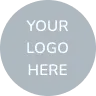

ERROR:root:❌ Failed to upload batch 1: name 'datetime' is not defined
ERROR:root:❌ Failed to upload batch 2: name 'datetime' is not defined


✅ Uploaded 2 batches. Batch info logged at: /content/drive/MyDrive/openai_batches_log.csv


In [ ]:
import json
import csv

BATCH_SIZE = 50
RETRIES = 3
client = OpenAI()

logging.info(f"Loading unlabeled dataset: {UNLABELED_DATASET_PATH}")
unlabeled_dataset = load_dataset(UNLABELED_DATASET_PATH, split="train")


try:
    existing_dataset = load_dataset(OUTPUT_DATASET_PATH, split="train")
    processed_ids = set(existing_dataset["ID"])
    logging.info(f"Loaded existing output dataset with {len(processed_ids)} entries.")
except Exception:
    logging.info("No existing output dataset found. Starting fresh.")
    processed_ids = set()

logging.info("Building batch requests...")

batch_inputs = []
for item in tqdm(unlabeled_dataset, desc="Preparing requests"):
    file_id = item["ID"]
    if not (651 <= file_id <= 750):
        continue


    if file_id in processed_ids:
        continue

    current_code = item["txt_file"]
    try:
        few_shots = retrieve_few_shots_algorithm5(current_code, NUM_FEW_SHOTS)
        system_prompt, user_prompt = build_prompt(few_shots, current_code)

        batch_inputs.append({
            "custom_id": str(file_id),
            "method": "POST",
            "url": "/v1/chat/completions",
            "body": {
                "model": MODEL,
                "messages": [
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": user_prompt},
                ],
                "temperature": 0.2,
                "max_tokens": 4000
            }
        })
    except Exception as e:
        logging.error(f"Few-shot retrieval failed for {file_id}: {e}")

logging.info(f"Total prepared requests: {len(batch_inputs)}")

print(batch_inputs)

def chunk_list(lst, n):
    for i in range(0, len(lst), n):
        yield lst[i:i + n]

batches = list(chunk_list(batch_inputs, BATCH_SIZE))

BATCH_LOG_PATH = "/content/drive/MyDrive/openai_batches_log.csv"

batch_ids = []

if not os.path.exists(BATCH_LOG_PATH):
    with open(BATCH_LOG_PATH, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow(["batch_number", "num_requests", "batch_id", "batch_file_path", "timestamp"])

for i, batch in enumerate(batches):
    batch_file_path = f"/content/batch_upload_{i}.jsonl"

    with open(batch_file_path, "w", encoding="utf-8") as f:
        for entry in batch:
            f.write(json.dumps(entry) + "\n")

    try:
        batch_file = client.files.create(
            file=open(batch_file_path, "rb"),
            purpose="batch"
        )

        batch_job = client.batches.create(
            input_file_id=batch_file.id,
            endpoint="/v1/chat/completions",
            completion_window="24h"
        )

        batch_ids.append(batch_job.id)

        with open(BATCH_LOG_PATH, "a", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow([
                i + 1,
                len(batch),
                batch_job.id,
                batch_file_path,
                datetime.now().strftime("%Y-%m-%d %H:%M:%S")
            ])

        logging.info(f" Batch {i+1}/{len(batches)} uploaded (ID: {batch_job.id})")

    except Exception as e:
        logging.error(f" Failed to upload batch {i+1}: {e}")
        time.sleep(5)

logging.info(f" Uploaded {len(batch_ids)} batches. Log saved to {BATCH_LOG_PATH}")
print(f" Uploaded {len(batch_ids)} batches. Batch info logged at: {BATCH_LOG_PATH}")


In [ ]:
# Receiving processed batches and saving results in HF
import os
import json
import pandas as pd
from datasets import Dataset, concatenate_datasets, load_dataset
from openai import OpenAI

# --- CONFIG ---
# client = OpenAI()

batch_ids = [
    "batch_69197e5b6ba88190adb2fef61f057bca",
    "batch_69197e627acc819087654dfcae5ecaba",
    "batch_69197bae72a88190b16963909e2f3278",
    "batch_69197bb666e881909757153e8104bb7f",
    "batch_69189695d2ac8190831d187879ef37dd",
    "batch_69189336075881908cc8ad5177145d51",
    "batch_6918933cbbf48190bff44ce2702ce919",
    "batch_69188df730b081909cfcadfb65216555",
    "batch_69188dfd66dc8190bf7345642f081d68",
    "batch_69188aeb88f08190be0deac8f0d287fe",
    "batch_69188af20c248190afde0d3027739f03",
    "batch_69158a0e45b48190801d7814ac917876",
    "batch_69158a15067c8190b2ce4913242d1720",
]

BATCH_RESULTS_DIR = "/content/drive/MyDrive/batch_results"
os.makedirs(BATCH_RESULTS_DIR, exist_ok=True)

result_files = []
for batch_id in batch_ids:
    print(f" Downloading results for {batch_id} ...")
    result = client.batches.retrieve(batch_id)
    result_file_id = result.output_file_id

    if not result_file_id:
        print(f" No result file for batch {batch_id}, skipping.")
        continue

    local_path = os.path.join(BATCH_RESULTS_DIR, f"{batch_id}_results.jsonl")
    with open(local_path, "wb") as f:
        content = client.files.content(result_file_id)
        f.write(content.read())
    result_files.append(local_path)

print(f" Downloaded {len(result_files)} result files.")

records = []
for file_path in result_files:
    print(f" Reading {file_path} ...")
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            try:
                data = json.loads(line)
                file_id = data.get("custom_id")  # our dataset ID
                business_rule = data["response"]["body"]["choices"][0]["message"]["content"]
                records.append({"ID": file_id, "business_rule": business_rule})
            except Exception as e:
                print(f" Failed to parse line in {file_path}: {e}")

print(f" Parsed {len(records)} total results.")

if not records:
    print(" No data found, skipping dataset upload.")
else:
    new_ds = Dataset.from_pandas(pd.DataFrame(records))

    try:
        existing_ds = load_dataset(OUTPUT_DATASET_PATH, split="train")
        combined = concatenate_datasets([existing_ds, new_ds])
    except Exception:
        combined = new_ds

    combined.push_to_hub(OUTPUT_DATASET_PATH)
    print(f" Uploaded {len(new_ds)} new results to {OUTPUT_DATASET_PATH}.")


In [ ]:
# Test
import json

path = "/content/drive/MyDrive/batch_results/batch_69158a0e45b48190801d7814ac917876_results.jsonl"

with open(path, "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        if i < 3:  
            print("----- LINE", i, "-----")
            try:
                data = json.loads(line)
                print(json.dumps(data, indent=2)[:1000]) 
            except Exception as e:
                print("Error parsing:", e)


----- LINE 0 -----
{
  "id": "batch_req_69158a60c7908190840af5c220ae36b8",
  "custom_id": "1",
  "response": {
    "status_code": 200,
    "request_id": "b37f877626b774a625d637827dfdeef3",
    "body": {
      "id": "chatcmpl-CbM8sdsnycrf1oailtjyRPPAA1Q8H",
      "object": "chat.completion",
      "created": 1763019286,
      "model": "gpt-4.1-2025-04-14",
      "choices": [
        {
          "index": 0,
          "message": {
            "role": "assistant",
            "content": "# Business Rules for Booking Unit Type Availability\n\n## 1. Required Information\n- Both **Arrival Date** and **Departure Date** must be provided to check unit type availability.\n- If a **Property ID** is provided, it must correspond to a valid property.\n\n## 2. Unit Type Availability Assessment\n- Only **active units** are considered when determining availability.\n- A unit is considered **available** if it has no booking conflicts and no block date conflicts for the requested period.\n- The total numb